# BDA Gastronomía — Notebook 2: Pipeline NLP + LDA
### Databricks · Spark MLlib · TF-IDF · LDA

> **Prerequisito:** Ejecutar primero el Notebook 1 (KMeans).  
> Este notebook inicia con cache de sesión vacío — necesario para NLP + LDA.


## 0 · Imports y configuración

In [0]:
from pyspark.sql import SparkSession, functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Tokenizer, StopWordsRemover, CountVectorizer, IDF,
)
from pyspark.ml.clustering import LDA

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import gc

spark = SparkSession.builder.getOrCreate()

# ── Catálogo y schema ─────────────────────────────────────────────────────────
CATALOGO = 'proyecto_bda'
SCHEMA   = 'bda_schema'

TBL_GOLD_FINAL = f'{CATALOGO}.{SCHEMA}.gold_reviews_final'

VOL_GESTIONADO = 'bda_volumen'
VOL_MODELOS    = 'bda_modelos'

VOLUMEN_BASE    = f'/Volumes/{CATALOGO}/{SCHEMA}/{VOL_GESTIONADO}'
VOLUMEN_MODELOS = f'/Volumes/{CATALOGO}/{SCHEMA}/{VOL_MODELOS}'

RUTA_MODELO_NLP = f'{VOLUMEN_MODELOS}/modelo_nlp_tfidf'
RUTA_MODELO_LDA = f'{VOLUMEN_MODELOS}/modelo_lda'

spark.sql(f'USE CATALOG {CATALOGO}')
spark.sql(f'USE SCHEMA {SCHEMA}')

print('Volumen modelos :', VOLUMEN_MODELOS)
print('Rutas listas.')


Volumen modelos : /Volumes/proyecto_bda/bda_schema/bda_modelos
Rutas listas.


## 1 · Carga de datos desde Gold

In [0]:
df = spark.table(TBL_GOLD_FINAL)
df.createOrReplaceTempView('gold')
print(f'Registros en Gold: {df.count():,}')


Registros en Gold: 2,764,295


## 2 · Stopwords en español

In [0]:
SPANISH_STOPS = [
    'de','la','que','el','en','y','a','los','del','se','las','por','un','para',
    'con','no','una','su','al','lo','como','más','pero','sus','le','ya','o',
    'este','sí','porque','esta','entre','cuando','muy','sin','sobre','también',
    'me','hasta','hay','donde','quien','desde','todo','nos','durante','todos',
    'uno','les','ni','contra','otros','ese','eso','ante','ellos','e','esto',
    'mí','antes','algunos','qué','unos','yo','otro','otras','otra','él','tanto',
    'esa','estos','mucho','quienes','nada','muchos','cual','poco','ella','estar',
    'estas','algunas','algo','nosotros','mi','mis','tú','te','ti','tu','tus',
    'ellas','nos','vosotros','vosotras','os','mío','mía','míos','mías','tuyo',
    'si','lugar','sitio','vez','mas','ser','hacer','ir','muy','bien','todo',
    'nada','así','aquí','café','restaurante','local','comida','lima','peru',
]
print(f'Stopwords cargadas: {len(SPANISH_STOPS)}')


Stopwords cargadas: 120


## 3 · Selección del corpus NLP

In [0]:
# Reducido a 0.08 para no exceder el cache de 1GB con NLP + LDA en la misma sesión
sdf_nlp = (
    df.select('id_review', 'caption_clean', 'sentimiento')
    .filter(F.col('caption_clean').isNotNull() & (F.length('caption_clean') > 20))
    .sample(fraction=0.08, seed=42)
)
print(f'Reseñas para NLP: {sdf_nlp.count():,}')


Reseñas para NLP: 88,894


## 4 · Pipeline NLP - TF-IDF con Spark MLlib
`Tokenizer` → `StopWordsRemover` → `CountVectorizer` → `IDF`


In [0]:
tokenizer = Tokenizer(inputCol='caption_clean', outputCol='tokens_raw')
remover   = StopWordsRemover(inputCol='tokens_raw', outputCol='tokens',
                              stopWords=SPANISH_STOPS, caseSensitive=False)
cv  = CountVectorizer(inputCol='tokens', outputCol='tf_vector',
                      maxDF=0.85, minDF=5.0, vocabSize=10_000)
idf = IDF(inputCol='tf_vector', outputCol='tfidf_vector', minDocFreq=5)

pipeline_nlp = Pipeline(stages=[tokenizer, remover, cv, idf])
modelo_nlp   = pipeline_nlp.fit(sdf_nlp)
sdf_tfidf    = modelo_nlp.transform(sdf_nlp)

print('Pipeline NLP entrenado')
print(f'Vocabulario real aprendido: {len(modelo_nlp.stages[2].vocabulary)}')
sdf_tfidf.select('id_review', 'tokens', 'tfidf_vector').show(5, truncate=80)


Pipeline NLP entrenado
Vocabulario real aprendido: 9419
+--------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                           id_review|                                                                          tokens|                                                                    tfidf_vector|
+--------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                 ChZDSUhNMG9nS0VJQ0FnSUNXeHVyeWR3EAE|                [mucha, variedadexelente, atención, precios, alcance, bolsillos]|(9419,[1,20,127,1627,3689],[1.4231775193795297,3.110454583760237,4.4954880696...|
|           

## 5 · Guardar modelo NLP en Azure

In [0]:
print('Guardando NLP...')
modelo_nlp.write().overwrite().save(RUTA_MODELO_NLP)
print(f'OK → {RUTA_MODELO_NLP}')


Guardando NLP...
OK → /Volumes/proyecto_bda/bda_schema/bda_modelos/modelo_nlp_tfidf


## 6 · Modelado de Tópicos - LDA con Spark MLlib
`LDA` de `pyspark.ml.clustering` - corre distribuido sobre el corpus TF vectorizado.


In [0]:
import gc

vocab = modelo_nlp.stages[2].vocabulary

# Liberar sdf_tfidf antes de LDA para aliviar cache
del sdf_tfidf
gc.collect()

lda = LDA(
    featuresCol='tf_vector',
    k=5,
    maxIter=20,            # subido de 5 -> 20: con 'em'/5 iter el modelo no converge y los 5 topicos salen identicos
    optimizer='online',    # 'em'/pocas iter colapsa los topicos; 'online' converge mejor en corpus disperso (igual que Spark_2)
    learningOffset=50.0,
    seed=42
)

# Re-transformar desde el pipeline NLP
sdf_tfidf_lda = modelo_nlp.transform(sdf_nlp)
modelo_lda    = lda.fit(sdf_tfidf_lda)

loglik  = modelo_lda.logLikelihood(sdf_tfidf_lda)
logperp = modelo_lda.logPerplexity(sdf_tfidf_lda)
print(f'Log-Verosimilitud : {loglik:.2f}')
print(f'Log-Perplejidad   : {logperp:.4f}  (cuanto menor, mejor)')


Log-Verosimilitud : -6286103.10
Log-Perplejidad   : 7.2593  (cuanto menor, mejor)


In [0]:
topics_df = modelo_lda.describeTopics(maxTermsPerTopic=10)

print('=' * 60)
for row in topics_df.collect():
    top_words = [vocab[i] for i in row['termIndices']]
    print(f"Tópico {row['topic']}: {' | '.join(top_words)}")
print('=' * 60)


Tópico 0: es | fue | agradable | ambiente | amable | pizza | personal | estaba | servicio | primera
Tópico 1: pollo | es | estaba |  | papas | pedí | brasa | pedimos | rico | platos
Tópico 2: es | buena | son | buen | mejor | precios | platos | precio | atención | calidad
Tópico 3: buena | atención |  | excelente | buen | ambiente | servicio | rico | recomendado | agradable
Tópico 4:  | atención | es | servicio | excelente | bueno | sabor | recomiendo | buen | ceviche


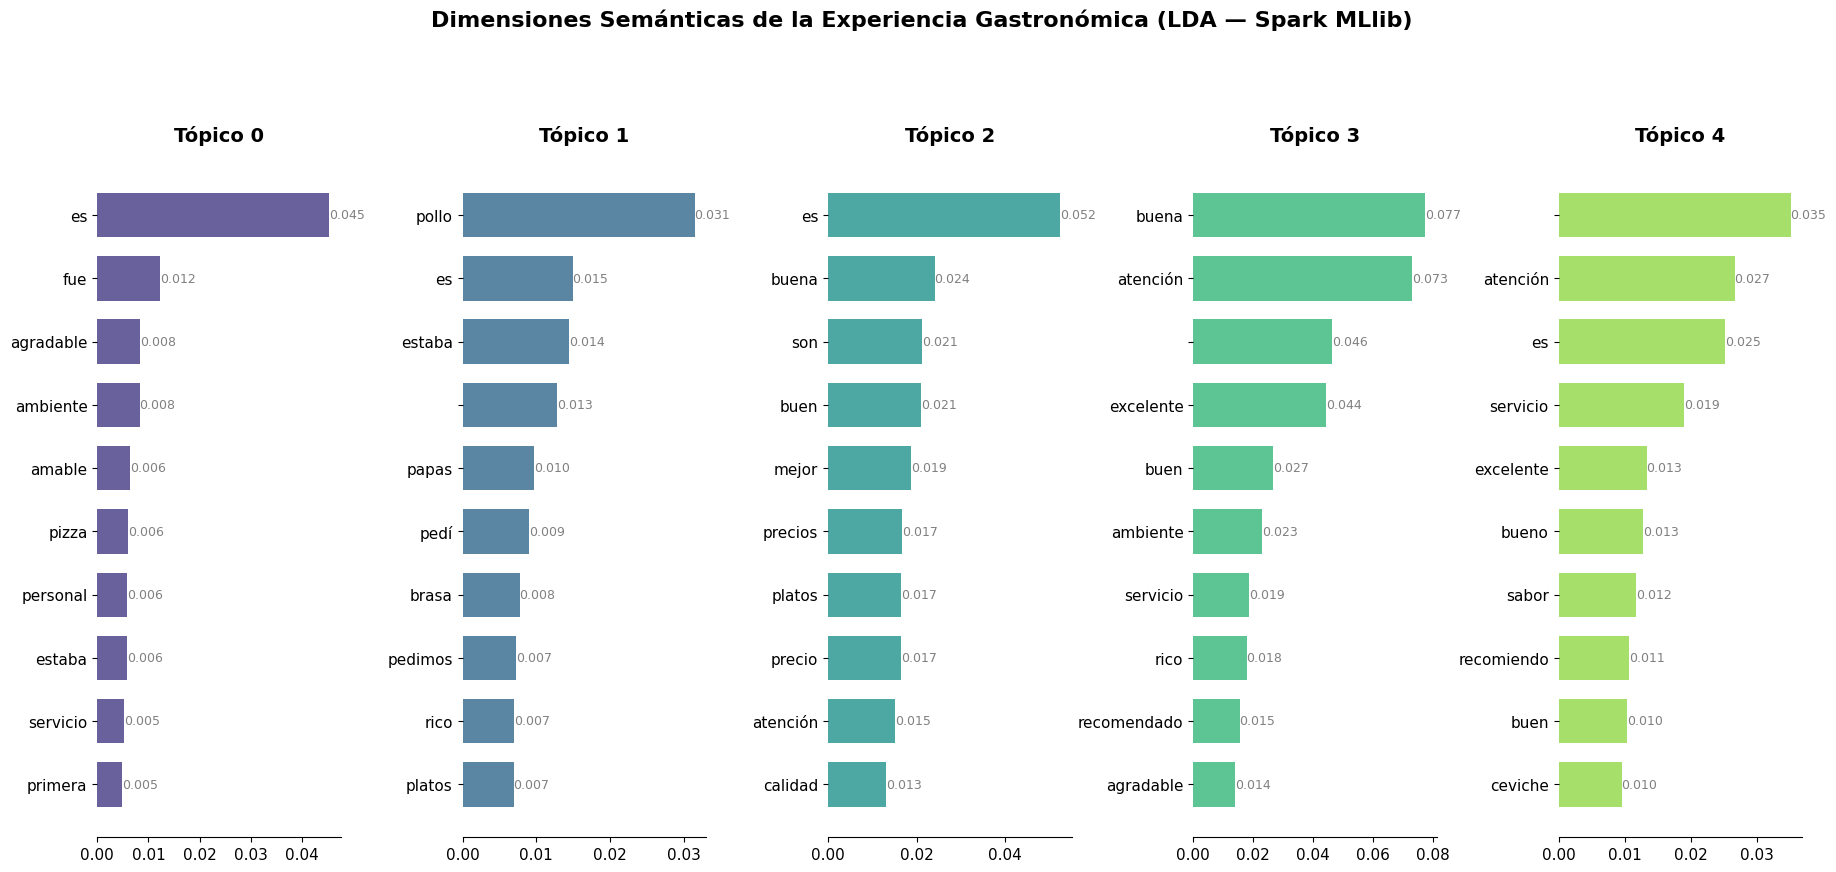

In [0]:
topics_pd = topics_df.toPandas()

fig, axes = plt.subplots(1, 5, figsize=(22, 9), sharey=False)
palette = sns.color_palette('viridis', 5)

for _, row in topics_pd.iterrows():
    idx       = int(row['topic'])
    top_words = [vocab[i] for i in row['termIndices']]
    weights   = [row['termWeights'][j] for j in range(len(row['termIndices']))]
    ax        = axes[idx]

    bars = ax.barh(top_words, weights, height=0.7, color=palette[idx], alpha=0.8)
    ax.set_title(f'Tópico {idx}', fontdict={'fontsize': 14, 'fontweight': 'bold'}, pad=15)
    ax.invert_yaxis()
    ax.tick_params(axis='both', which='major', labelsize=11)
    for bar in bars:
        w = bar.get_width()
        ax.text(w, bar.get_y() + bar.get_height() / 2,
                f'{w:.3f}', va='center', ha='left', fontsize=9, color='gray')
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

fig.suptitle('Dimensiones Semánticas de la Experiencia Gastronómica (LDA — Spark MLlib)',
             fontsize=16, fontweight='bold', y=1.02)
plt.subplots_adjust(top=0.85, bottom=0.1, wspace=0.5)
plt.show()


In [0]:
# Tópico dominante por reseña
@F.udf(returnType='int')
def argmax_udf(v):
    arr = v.toArray()
    return int(arr.argmax())

sdf_topics = modelo_lda.transform(sdf_tfidf_lda)
sdf_topics = sdf_topics.withColumn('topico_dominante', argmax_udf(F.col('topicDistribution')))
display(sdf_topics.groupBy('topico_dominante').count().orderBy('topico_dominante'))


topico_dominante,count
0,11926
1,9547
2,23341
3,27180
4,16900


## 7 · Guardar modelo LDA en Azure

In [0]:
print('Guardando LDA...')
modelo_lda.write().overwrite().save(RUTA_MODELO_LDA)
print(f'OK → {RUTA_MODELO_LDA}')


Guardando LDA...
OK → /Volumes/proyecto_bda/bda_schema/bda_modelos/modelo_lda


## 8 · Verificación final

In [0]:
print('Modelos guardados en Azure:')
print(f'  NLP : {RUTA_MODELO_NLP}')
print(f'  LDA : {RUTA_MODELO_LDA}')
print()
display(spark.sql(f"SHOW VOLUMES IN {CATALOGO}.{SCHEMA}"))


Modelos guardados en Azure:
  NLP : /Volumes/proyecto_bda/bda_schema/bda_modelos/modelo_nlp_tfidf
  LDA : /Volumes/proyecto_bda/bda_schema/bda_modelos/modelo_lda



database,volume_name
bda_schema,bda_modelos
bda_schema,bda_volumen


## Resumen — Componentes Spark MLlib utilizados

| Paso | Clase MLlib | Reemplaza a |
|------|-------------|-------------|
| Ensamblado de features | `VectorAssembler` | `np.array` / columnas pandas |
| Escalado | `StandardScaler` | `sklearn.preprocessing.StandardScaler` |
| Clustering | `KMeans` (MLlib) | `sklearn.cluster.KMeans` |
| Evaluación clustering | `ClusteringEvaluator` | `sklearn.metrics.silhouette_score` |
| Tokenización | `Tokenizer` | `str.split` / `nltk.word_tokenize` |
| Eliminación stopwords | `StopWordsRemover` | stopwords de `nltk` |
| Vectorización TF | `CountVectorizer` | `sklearn.feature_extraction.text.CountVectorizer` |
| Ponderación TF-IDF | `IDF` | `sklearn.feature_extraction.text.TfidfVectorizer` |
| Modelado de tópicos | `LDA` (MLlib) | `sklearn.decomposition.LatentDirichletAllocation` |
| Orquestación | `Pipeline` (MLlib) | scripts secuenciales |

> **Beneficio:** ningún `collect()` / `.toPandas()` sobre el dataset completo.  
> Los +1.2 M registros se procesan en el cluster de forma distribuida.
